<h1><center>Discriminator — Project Notes</center></h1>

**RL-Based Beat Generation | CS 5180 Final Project**

This notebook documents the design decisions, intuitions, and implementation of the Level 1 Discriminator — the neural network that judges whether a beat grid looks like a real human performance or agent-generated output.

---

<h2><center>1. What is the beat grid?</center></h2>

The beat grid is the core data structure of our project. It's exactly what a drum machine shows — a 2D grid where:
- **Rows** = instruments (Kick, Snare, Hi-hat, Clap)
- **Columns** = time steps (16 sixteenth notes = 1 bar)
- **Each cell** = 0 (silent) or 1 (sound plays)

Phase 1 uses a **4×16 grid** (drums only). Phase 2 expands to **8×16** (adds bass, melody, pad, fx).

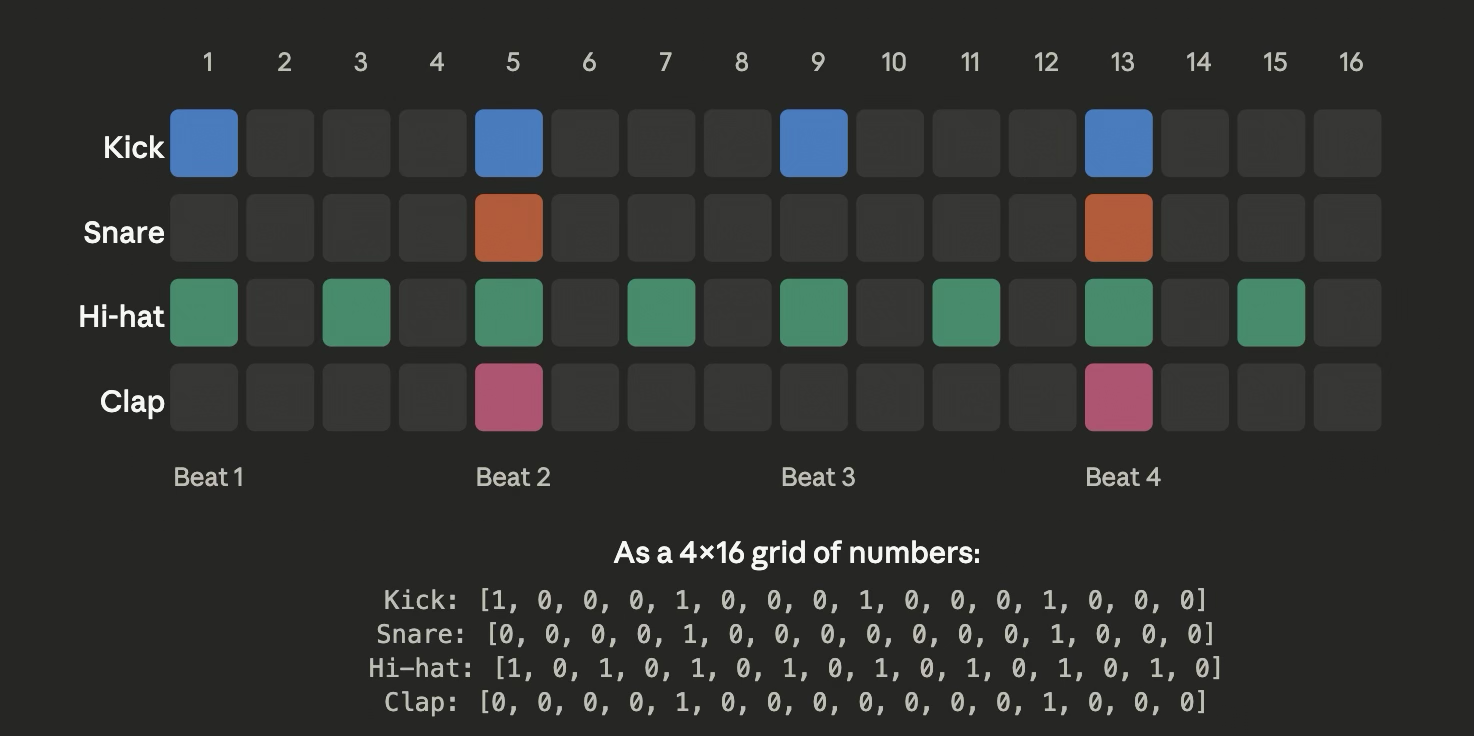

In [1]:
# === All imports (run this cell first) ===
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math

# Example: a classic drum pattern as a 4x16 grid
instruments = ['Kick', 'Snare', 'Hi-hat', 'Clap']
colors = ['#378ADD', '#D85A30', '#1D9E75', '#D4537E']

beat_grid = np.array([
    # steps:  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],  # Kick   — four-on-the-floor
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],  # Snare  — backbeats (2 & 4)
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],  # Hi-hat — eighth notes
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],  # Clap   — layered with snare
])

print(f"Grid shape: {beat_grid.shape}")
print(f"Total active cells: {beat_grid.sum()} / {beat_grid.size}")
print(f"Onset density: {beat_grid.sum() / beat_grid.size:.2f}")


Grid shape: (4, 16)
Total active cells: 16 / 64
Onset density: 0.25


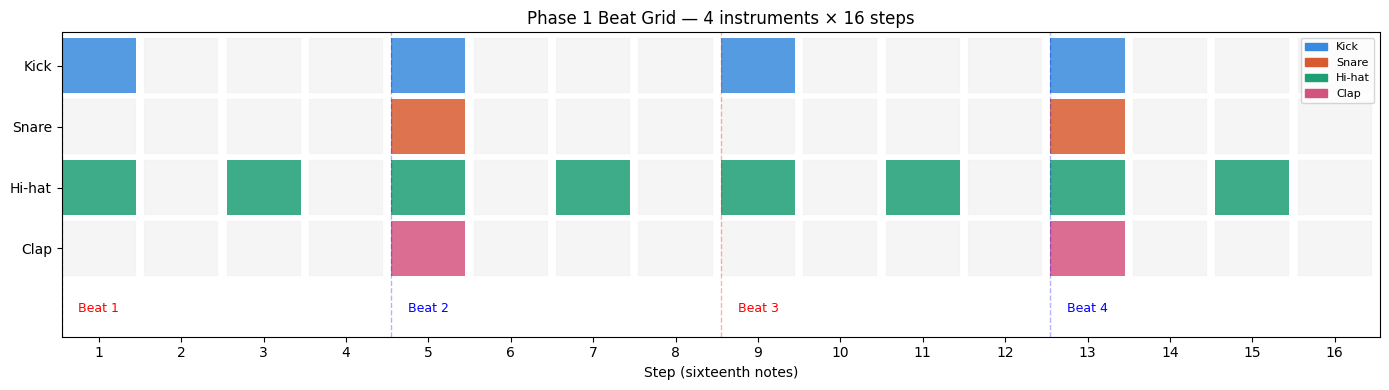

In [2]:
# Visualize the beat grid
fig, ax = plt.subplots(figsize=(14, 4))

for row in range(4):
    for col in range(16):
        if beat_grid[row, col] == 1:
            ax.add_patch(plt.Rectangle((col, 3 - row), 0.9, 0.9, 
                                        facecolor=colors[row], alpha=0.85, edgecolor='none'))
        else:
            ax.add_patch(plt.Rectangle((col, 3 - row), 0.9, 0.9, 
                                        facecolor='gray', alpha=0.08, edgecolor='gray', linewidth=0.3))

# Beat markers
for beat_num, step in enumerate([0, 4, 8, 12], 1):
    ax.axvline(x=step, color='red' if beat_num in [1,3] else 'blue', 
               alpha=0.3, linewidth=1, linestyle='--')
    ax.text(step + 0.45, -0.6, f'Beat {beat_num}', ha='center', fontsize=9, 
            color='red' if beat_num in [1,3] else 'blue')

ax.set_yticks([0.45, 1.45, 2.45, 3.45])
ax.set_yticklabels(instruments[::-1])
ax.set_xticks([i + 0.45 for i in range(16)])
ax.set_xticklabels([str(i+1) for i in range(16)])
ax.set_xlim(0, 16)
ax.set_ylim(-1, 4)
ax.set_xlabel('Step (sixteenth notes)')
ax.set_title('Phase 1 Beat Grid — 4 instruments × 16 steps')
ax.legend(handles=[mpatches.Patch(color=c, label=inst) for inst, c in zip(instruments, colors)],
          loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


<h2><center>2. What does the discriminator do?</center></h2>

The discriminator is a **binary classifier**. It takes a beat grid as input and outputs a single number between 0 and 1:
- **Close to 1** → "This looks like a real human beat pattern"
- **Close to 0** → "This looks fake / randomly generated"

<h3><center>Why do we need it?</center></h3>

Our PPO agent generates beat patterns. But how do we know if they're any good? We have two types of feedback:
1. **Rule-based rewards** — hand-coded rules (kick on strong beats, density between 0.3–0.6, etc.)
2. **Discriminator reward** — a learned judge trained on real human beats

The discriminator captures subtle patterns that are hard to write rules for — the "feel" of a real beat that goes beyond just following rules.

<h3><center>Training data</center></h3>
- **Real (label=1):** 42,133 drum grids from Groove MIDI dataset (real human performances)
- **Fake (label=0):** Random grids, shuffled real grids, and agent-generated grids

The total reward combines both: `R_total = α × R_rules + β × R_discriminator`

<h2><center>3. Why a transformer instead of a CNN?</center></h2>

This is a key architecture decision. Both CNNs and transformers can process the 4×16 grid, but they "see" patterns differently.

<h3><center>CNN — sliding window approach</center></h3>

A CNN slides a small filter (e.g. 3×3) across the grid. At each position, it can only see what's inside that window.

**Problem for beats:** The kick on step 1 and the snare on step 5 are 4 steps apart. A 3×3 filter can never see both at once. You'd need to stack many CNN layers so that the "receptive field" gradually grows large enough to connect distant steps.

<h3><center>Transformer — self-attention approach</center></h3>

A transformer looks at ALL steps simultaneously. Each step computes an "attention score" with every other step, asking: "how relevant is that step to understanding me?"

**Why this fits beats:** The kick-snare backbeat relationship (steps 1↔5), the hi-hat regularity across ALL steps, the clap layering with snare — these are all **long-range dependencies** that self-attention captures in a single operation.

<h3><center>Quick analogy</center></h3>
- **CNN** = reading a book through a magnifying glass that only shows 3 words at a time. You can see local grammar, but understanding the plot requires many passes.
- **Transformer** = seeing the entire page at once and drawing lines between related words. You immediately see that the subject in paragraph 1 connects to the verb in paragraph 3.

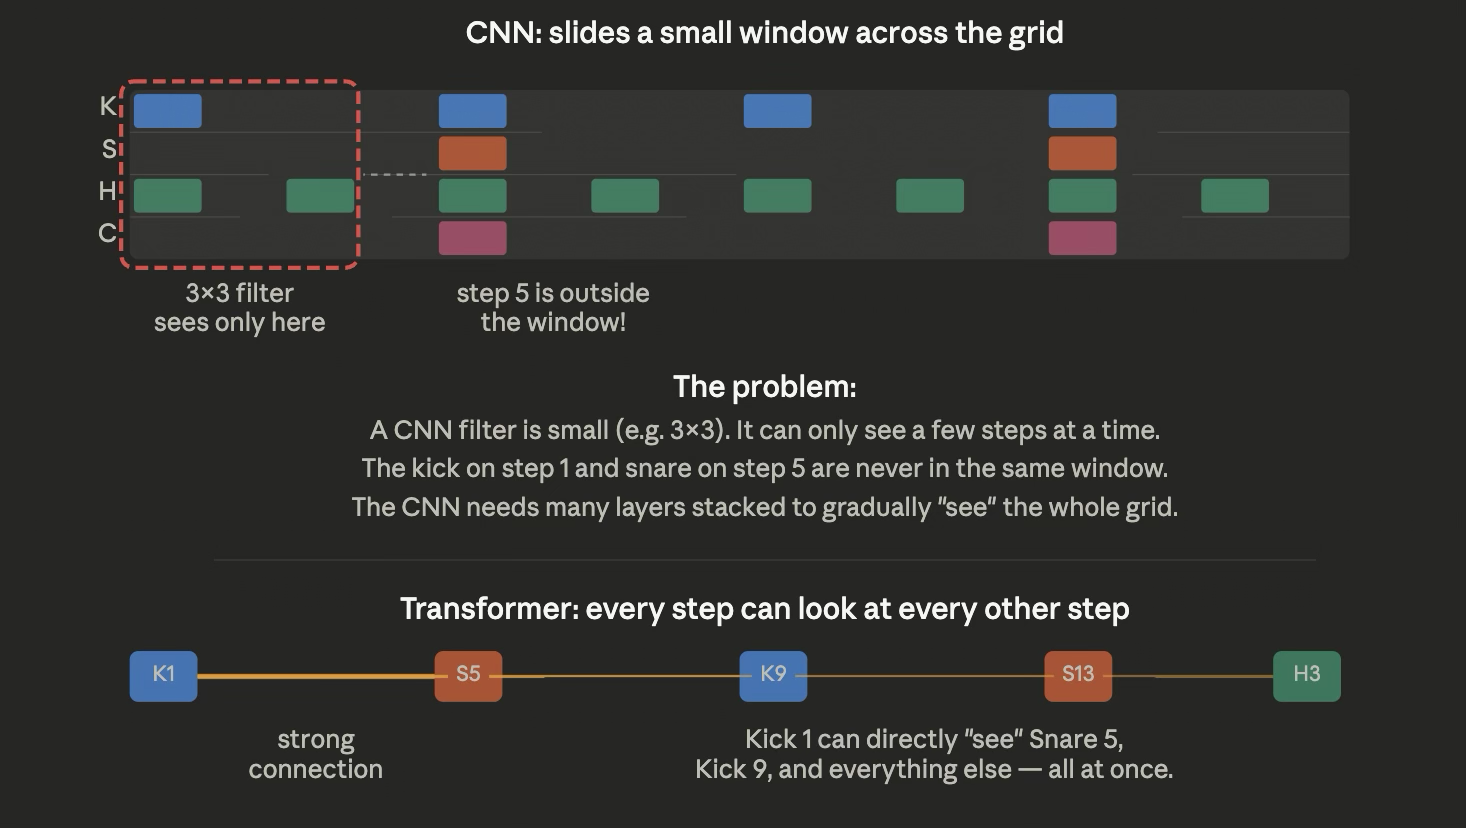

In [3]:
# Concrete example: what a CNN filter vs attention sees

print("=" * 60)
print("CNN 3x3 filter at position (0, 0):")
print("=" * 60)
print("Can see:")
print(f"  Kick   steps 1-3: {beat_grid[0, 0:3]}")
print(f"  Snare  steps 1-3: {beat_grid[1, 0:3]}")
print(f"  Hi-hat steps 1-3: {beat_grid[2, 0:3]}")
print()
print("Cannot see: Snare on step 5, Kick on step 9, etc.")
print("To see kick→snare backbeat pattern, need receptive field ≥ 5 steps")
print()

print("=" * 60)
print("Transformer self-attention for Kick step 1:")
print("=" * 60)
print("Can see ALL steps simultaneously:")
for i, inst in enumerate(instruments):
    active = [s+1 for s in range(16) if beat_grid[i, s] == 1]
    print(f"  {inst:8s}: active at steps {active}")
print()
print("Kick step 1 directly attends to Snare step 5 → learns backbeat")
print("Kick step 1 directly attends to Hi-hat steps 1,3,5... → learns pulse")

CNN 3x3 filter at position (0, 0):
Can see:
  Kick   steps 1-3: [1 0 0]
  Snare  steps 1-3: [0 0 0]
  Hi-hat steps 1-3: [1 0 1]

Cannot see: Snare on step 5, Kick on step 9, etc.
To see kick→snare backbeat pattern, need receptive field ≥ 5 steps

Transformer self-attention for Kick step 1:
Can see ALL steps simultaneously:
  Kick    : active at steps [1, 5, 9, 13]
  Snare   : active at steps [5, 13]
  Hi-hat  : active at steps [1, 3, 5, 7, 9, 11, 13, 15]
  Clap    : active at steps [5, 13]

Kick step 1 directly attends to Snare step 5 → learns backbeat
Kick step 1 directly attends to Hi-hat steps 1,3,5... → learns pulse


<h2><center>4. Self-attention — step by step with code</center></h2>

Let's implement self-attention from scratch using our beat grid. We'll work with just 5 time steps to keep the numbers readable.

<h3><center>Step 1: Represent each step as a vector</center></h3>

Each step in the grid needs to become a vector (a list of numbers) that describes it. For now, we'll just use the raw grid column — a 4-number vector saying which instruments are active.


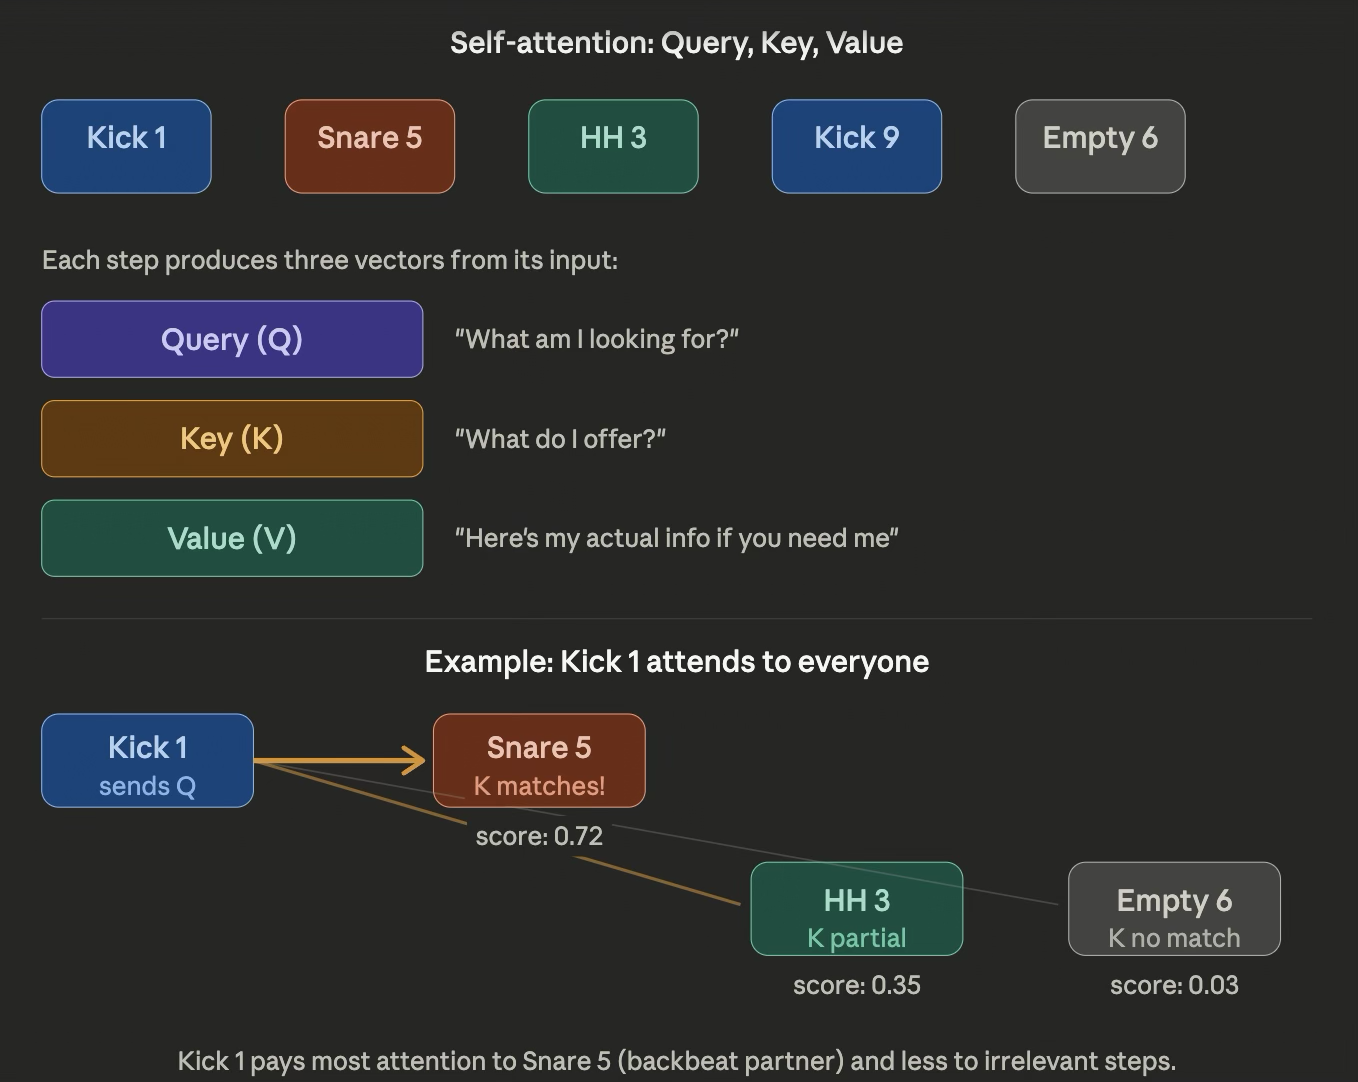

In [4]:
# Using beat_grid from cell 2 (no need to redefine)

# Pick 5 steps to work with: steps 1, 3, 5, 6, 9 (0-indexed: 0, 2, 4, 5, 8)
step_indices = [0, 2, 4, 5, 8]
step_names = ["Step1(K)", "Step3(HH)", "Step5(K+S+HH+C)", "Step6(empty)", "Step9(K+HH)"]

# Each step becomes a column vector from the grid
# Shape: (5 steps, 4 instruments)
X = torch.tensor(beat_grid[:, step_indices].T, dtype=torch.float32)

print("Input vectors (each row = one step, each column = instrument [K, S, HH, C]):")
print(f"{'Step':<22} {'Kick':>4} {'Snare':>5} {'HH':>4} {'Clap':>4}")
print("-" * 42)
for i, name in enumerate(step_names):
    print(f"{name:<22} {X[i][0]:>4.0f} {X[i][1]:>5.0f} {X[i][2]:>4.0f} {X[i][3]:>4.0f}")


Input vectors (each row = one step, each column = instrument [K, S, HH, C]):
Step                   Kick Snare   HH Clap
------------------------------------------
Step1(K)                  1     0    1    0
Step3(HH)                 0     0    1    0
Step5(K+S+HH+C)           1     1    1    1
Step6(empty)              0     0    0    0
Step9(K+HH)               1     0    1    0


<h3><center>Step 2: Create Q, K, V with linear transformations</center></h3>

In a real transformer, Q, K, V are created by multiplying the input by learned weight matrices. The network learns WHAT to look for (Q weights), WHAT to advertise (K weights), and WHAT info to share (V weights).

For this example we'll use small 4→4 weight matrices so you can trace every number.


In [5]:
# In practice these are learned. We'll use small random weights for demo.
torch.manual_seed(42)
d_model = 4  # input dimension (4 instruments)
d_k = 4      # Q/K/V dimension (keeping it same size for simplicity)

# Weight matrices — these are what the network LEARNS during training
W_Q = torch.randn(d_model, d_k) * 0.5  # Query weights
W_K = torch.randn(d_model, d_k) * 0.5  # Key weights
W_V = torch.randn(d_model, d_k) * 0.5  # Value weights

# Compute Q, K, V for all steps at once
# X shape: (5, 4) @ W shape: (4, 4) → output shape: (5, 4)
Q = X @ W_Q  # What each step is LOOKING FOR
K = X @ W_K  # What each step OFFERS
V = X @ W_V  # What info each step SHARES

print("Queries (Q) — what each step is looking for:")
for i, name in enumerate(step_names):
    print(f"  {name:<22} → [{Q[i][0]:>6.2f}, {Q[i][1]:>6.2f}, {Q[i][2]:>6.2f}, {Q[i][3]:>6.2f}]")

print(f"\nKeys (K) — what each step offers:")
for i, name in enumerate(step_names):
    print(f"  {name:<22} → [{K[i][0]:>6.2f}, {K[i][1]:>6.2f}, {K[i][2]:>6.2f}, {K[i][3]:>6.2f}]")


Queries (Q) — what each step is looking for:
  Step1(K)               → [  0.59,   1.57,   0.25,  -1.75]
  Step3(HH)              → [ -0.38,   0.82,  -0.20,  -0.70]
  Step5(K+S+HH+C)        → [  0.56,   0.67,  -0.15,  -2.18]
  Step6(empty)           → [  0.00,   0.00,   0.00,   0.00]
  Step9(K+HH)            → [  0.59,   1.57,   0.25,  -1.75]

Keys (K) — what each step offers:
  Step1(K)               → [  1.46,   0.57,   0.06,   0.89]
  Step3(HH)              → [  0.64,   0.65,   0.31,   0.67]
  Step5(K+S+HH+C)        → [  0.97,   1.13,   0.33,   2.16]
  Step6(empty)           → [  0.00,   0.00,   0.00,   0.00]
  Step9(K+HH)            → [  1.46,   0.57,   0.06,   0.89]


<h3><center>Step 3: Compute attention scores</center></h3>

Now the magic — compare every Query against every Key using a dot product. If Q and K point in similar directions, the dot product is large → high attention.

The formula is: `score(i, j) = Q[i] · K[j] / √d_k`

The `√d_k` part just prevents the scores from getting too big (it's a scaling factor).


In [6]:
# Attention scores: Q @ K^T / sqrt(d_k)
# Shape: (5, 4) @ (4, 5) → (5, 5) — every step vs every step
scores = (Q @ K.T) / np.sqrt(d_k)

print("Raw attention scores (before softmax):")
print(f"{'':>22}", end="")
for name in step_names:
    print(f"{name:>12}", end="")
print()
print("-" * 82)
for i, name in enumerate(step_names):
    print(f"{name:>22}", end="")
    for j in range(5):
        print(f"{scores[i][j]:>12.2f}", end="")
    print()

print(f"\nRead row-wise: each row shows how much that step attends to every other step.")
print(f"Example: Step1(K) attends to Step5(K+S+HH+C) with score {scores[0][2]:.2f}")


Raw attention scores (before softmax):
                          Step1(K)   Step3(HH)Step5(K+S+HH+C)Step6(empty) Step9(K+HH)
----------------------------------------------------------------------------------
              Step1(K)        0.10        0.15       -0.68        0.00        0.10
             Step3(HH)       -0.36       -0.12       -0.51        0.00       -0.36
       Step5(K+S+HH+C)       -0.37       -0.35       -1.72        0.00       -0.37
          Step6(empty)        0.00        0.00        0.00        0.00        0.00
           Step9(K+HH)        0.10        0.15       -0.68        0.00        0.10

Read row-wise: each row shows how much that step attends to every other step.
Example: Step1(K) attends to Step5(K+S+HH+C) with score -0.68


<h3><center>Step 4: Softmax — turn scores into probabilities</center></h3>

The raw scores can be any number. Softmax squashes them into probabilities that sum to 1. This means: each step distributes 100% of its attention across all steps.


In [7]:
# Softmax along the last dimension (each row sums to 1)
attention_weights = F.softmax(scores, dim=-1)

print("Attention weights (after softmax — each row sums to 1.0):")
print(f"{'':>22}", end="")
for name in step_names:
    print(f"{name:>12}", end="")
print()
print("-" * 82)
for i, name in enumerate(step_names):
    print(f"{name:>22}", end="")
    for j in range(5):
        w = attention_weights[i][j]
        marker = " ◀" if w == attention_weights[i].max() else ""
        print(f"{w:>10.3f}{marker}", end="")
    print(f"  (sum={attention_weights[i].sum():.2f})")

print(f"\n◀ marks the highest attention for each step.")
print(f"Notice: steps with similar instruments (both have kick) tend to attend to each other.")


Attention weights (after softmax — each row sums to 1.0):
                          Step1(K)   Step3(HH)Step5(K+S+HH+C)Step6(empty) Step9(K+HH)
----------------------------------------------------------------------------------
              Step1(K)     0.227     0.238 ◀     0.103     0.205     0.227  (sum=1.00)
             Step3(HH)     0.180     0.229     0.155     0.257 ◀     0.180  (sum=1.00)
       Step5(K+S+HH+C)     0.212     0.215     0.055     0.306 ◀     0.212  (sum=1.00)
          Step6(empty)     0.200 ◀     0.200 ◀     0.200 ◀     0.200 ◀     0.200 ◀  (sum=1.00)
           Step9(K+HH)     0.227     0.238 ◀     0.103     0.205     0.227  (sum=1.00)

◀ marks the highest attention for each step.
Notice: steps with similar instruments (both have kick) tend to attend to each other.


<h3><center>Step 5: Weighted sum of Values — the output</center></h3>

Each step collects information from all other steps, weighted by the attention scores. Steps with high attention contribute more to the output.


In [8]:
# Output = attention_weights @ V
# Shape: (5, 5) @ (5, 4) → (5, 4)
output = attention_weights @ V

print("Final output — each step now contains info from the steps it attended to:")
for i, name in enumerate(step_names):
    print(f"  {name:<22} → [{output[i][0]:>6.2f}, {output[i][1]:>6.2f}, {output[i][2]:>6.2f}, {output[i][3]:>6.2f}]")

print(f"\nKey insight: Step6(empty) started as [0,0,0,0] but now has non-zero values!")
print(f"It 'borrowed' information from its neighbors through attention.")
print(f"\nThis is the power of self-attention: every step's output is enriched")
print(f"by context from the ENTIRE sequence, not just its local neighborhood.")


Final output — each step now contains info from the steps it attended to:
  Step1(K)               → [ -1.05,   0.24,  -0.46,   0.17]
  Step3(HH)              → [ -1.01,   0.28,  -0.46,   0.12]
  Step5(K+S+HH+C)        → [ -0.90,   0.18,  -0.38,   0.17]
  Step6(empty)           → [ -1.13,   0.31,  -0.51,   0.15]
  Step9(K+HH)            → [ -1.05,   0.24,  -0.46,   0.17]

Key insight: Step6(empty) started as [0,0,0,0] but now has non-zero values!
It 'borrowed' information from its neighbors through attention.

This is the power of self-attention: every step's output is enriched
by context from the ENTIRE sequence, not just its local neighborhood.


<h3><center>Step 6: Visualize the attention pattern</center></h3>


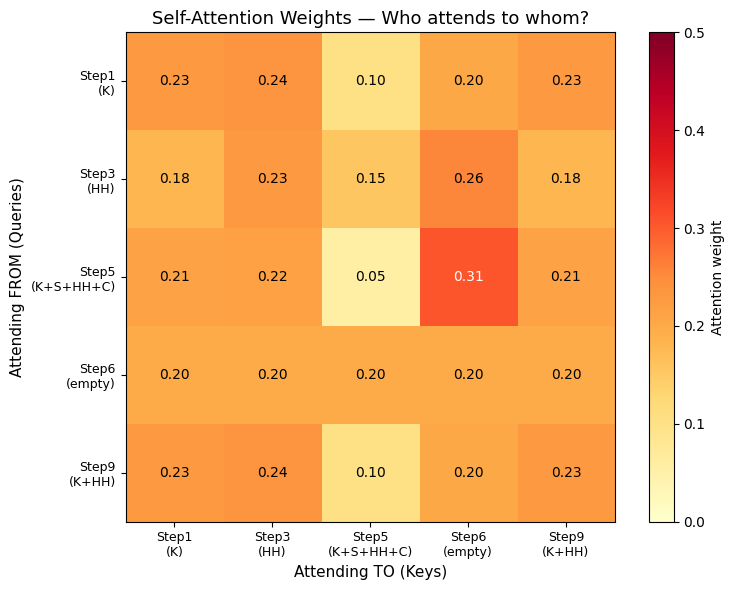

Brighter cells = stronger attention.
This heatmap is what the discriminator learns to produce — patterns of
attention that distinguish real beats from fake ones.


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(attention_weights.detach().numpy(), cmap='YlOrRd', vmin=0, vmax=0.5)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
short_names = ["Step1\n(K)", "Step3\n(HH)", "Step5\n(K+S+HH+C)", "Step6\n(empty)", "Step9\n(K+HH)"]
ax.set_xticklabels(short_names, fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)
ax.set_xlabel("Attending TO (Keys)", fontsize=11)
ax.set_ylabel("Attending FROM (Queries)", fontsize=11)
ax.set_title("Self-Attention Weights — Who attends to whom?", fontsize=13)

# Add text annotations
for i in range(5):
    for j in range(5):
        w = attention_weights[i][j].item()
        color = "white" if w > 0.3 else "black"
        ax.text(j, i, f"{w:.2f}", ha="center", va="center", fontsize=10, color=color)

plt.colorbar(im, label="Attention weight")
plt.tight_layout()
plt.show()

print("Brighter cells = stronger attention.")
print("This heatmap is what the discriminator learns to produce — patterns of")
print("attention that distinguish real beats from fake ones.")


<h2><center>5. Discriminator architecture — full implementation</center></h2>

We'll build this bottom-up, one class at a time:
1. `MultiHeadAttention` — runs our self-attention N times in parallel
2. `EncoderBlock` — attention + feed-forward + normalization
3. `BeatDiscriminator` — the full model (embed → encode → classify)

<h3><center>5.1 Multi-head attention</center></h3>

Remember: 4 heads = 4 separate attention computations in parallel, each with its own Q/K/V weights. Each head can specialize in a different musical relationship.


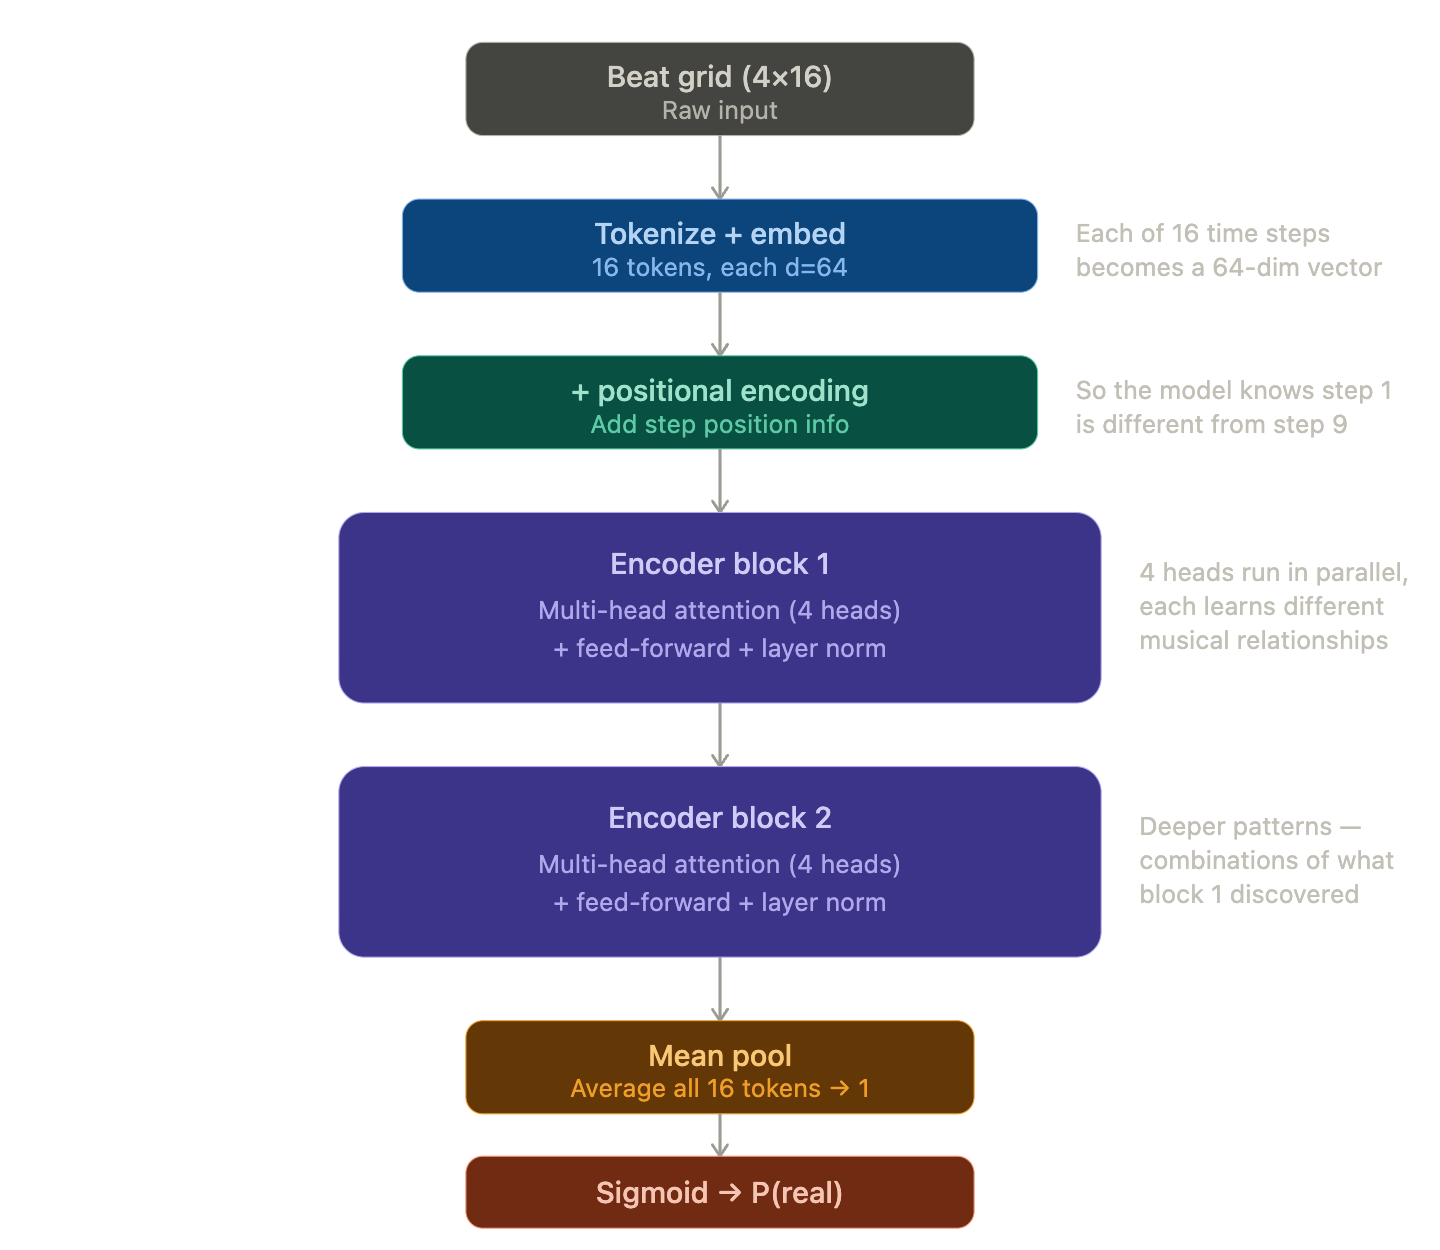

In [10]:
# Using imports from cell 2

class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention.
    
    Instead of one big attention with d_model dimensions,
    we split into num_heads smaller attentions, each with d_model // num_heads dimensions.
    This lets different heads learn different types of relationships.
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model      # Total dimension (64)
        self.num_heads = num_heads   # Number of parallel heads (4)
        self.d_k = d_model // num_heads  # Dimension per head (64/4 = 16)
        
        # One big linear layer for each of Q, K, V
        # (more efficient than separate layers per head)
        self.W_Q = nn.Linear(d_model, d_model)  # (64 → 64)
        self.W_K = nn.Linear(d_model, d_model)  # (64 → 64)
        self.W_V = nn.Linear(d_model, d_model)  # (64 → 64)
        
        # Final projection after concatenating heads
        self.W_out = nn.Linear(d_model, d_model)  # (64 → 64)
    
    def forward(self, x):
        batch_size, seq_len, _ = x.shape  # (B, 16, 64)
        
        # Step 1: Compute Q, K, V
        Q = self.W_Q(x)  # (B, 16, 64)
        K = self.W_K(x)
        V = self.W_V(x)
        
        # Step 2: Split into multiple heads
        # Reshape: (B, 16, 64) → (B, 16, 4, 16) → (B, 4, 16, 16)
        # Now each head operates on 16-dim vectors independently
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # Step 3: Attention scores (same formula as section 4!)
        # (B, 4, 16, 16) @ (B, 4, 16, 16)^T → (B, 4, 16, 16)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn_weights = F.softmax(scores, dim=-1)
        
        # Step 4: Weighted sum of values
        # (B, 4, 16, 16) @ (B, 4, 16, 16) → (B, 4, 16, 16)
        out = attn_weights @ V
        
        # Step 5: Concatenate heads back together
        # (B, 4, 16, 16) → (B, 16, 4, 16) → (B, 16, 64)
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        
        # Step 6: Final linear projection
        out = self.W_out(out)  # (B, 16, 64)
        
        return out, attn_weights  # Return weights too so we can visualize

# Quick test
mha = MultiHeadAttention(d_model=64, num_heads=4)
test_input = torch.randn(1, 16, 64)  # 1 beat, 16 steps, 64-dim
test_output, test_weights = mha(test_input)
print(f"Input shape:            {test_input.shape}")
print(f"Output shape:           {test_output.shape}")
print(f"Attention weights shape: {test_weights.shape}  (batch, heads, steps, steps)")
print(f"\nEach of the 4 heads produces a 16×16 attention matrix.")
print(f"Head 1 might focus on kick-snare, Head 2 on hi-hat regularity, etc.")



Input shape:            torch.Size([1, 16, 64])
Output shape:           torch.Size([1, 16, 64])
Attention weights shape: torch.Size([1, 4, 16, 16])  (batch, heads, steps, steps)

Each of the 4 heads produces a 16×16 attention matrix.
Head 1 might focus on kick-snare, Head 2 on hi-hat regularity, etc.


<h3><center>5.2 Encoder block</center></h3>

Each encoder block has:
1. **Multi-head attention** — find relationships between steps
2. **Add & norm** — residual connection + layer normalization (keeps training stable)
3. **Feed-forward network** — process each step independently (2 linear layers with ReLU)
4. **Add & norm** — another residual + normalization

The residual connection means: `output = LayerNorm(x + Attention(x))`. This lets gradients flow easily during training and prevents the "vanishing gradient" problem.


In [11]:
class EncoderBlock(nn.Module):
    """
    One transformer encoder block.
    
    Architecture:
        x → MultiHeadAttention → Add & LayerNorm → FeedForward → Add & LayerNorm → output
        |________________________↑                  |______________↑
              (residual connections — skip the sublayer and add input directly)
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        # Sub-layer 1: Multi-head attention
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        
        # Sub-layer 2: Feed-forward network
        # d_ff is the hidden dimension (usually 4x d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),     # Expand: 64 → 256
            nn.ReLU(),                     # Non-linearity
            nn.Linear(d_ff, d_model),      # Contract: 256 → 64
        )
        self.norm2 = nn.LayerNorm(d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # Sub-layer 1: Attention with residual connection
        attn_out, attn_weights = self.attention(x)
        x = self.norm1(x + self.dropout(attn_out))  # Residual: add input to output
        
        # Sub-layer 2: Feed-forward with residual connection
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))     # Residual again
        
        return x, attn_weights

# Quick test
block = EncoderBlock(d_model=64, num_heads=4, d_ff=256)
test_out, test_w = block(test_input)
print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {test_out.shape}  (same shape — that's the point of residuals)")
print(f"\nThe residual connection means even if attention learns nothing,")
print(f"the output is at least as good as the input (identity function).")


Input shape:  torch.Size([1, 16, 64])
Output shape: torch.Size([1, 16, 64])  (same shape — that's the point of residuals)

The residual connection means even if attention learns nothing,
the output is at least as good as the input (identity function).


<h3><center>5.3 The full discriminator</center></h3>

Now we stack everything together. This is the complete model that takes a 4×16 beat grid and outputs P(real).


In [12]:
class BeatDiscriminator(nn.Module):
    """
    Transformer-based discriminator for beat grids.
    
    Input:  Beat grid of shape (batch, num_instruments, num_steps)
            Phase 1: (B, 4, 16) — drums only
            Phase 2: (B, 8, 16) — full instrumentation
    
    Output: Probability that the beat is real, shape (batch, 1)
    
    Architecture:
        Grid → Embed each step → Add position info → 2 Encoder blocks → Mean pool → Sigmoid
    """
    def __init__(
        self,
        num_instruments=4,   # Phase 1: 4 drums. Phase 2: 8 instruments
        num_steps=16,        # 16 sixteenth notes per bar
        d_model=64,          # Embedding dimension
        num_heads=4,         # Attention heads per block
        num_blocks=2,        # Number of encoder blocks
        d_ff=256,            # Feed-forward hidden dimension
        dropout=0.1,
    ):
        super().__init__()
        
        self.num_steps = num_steps
        self.d_model = d_model
        
        # 1. Token embedding: project each step from num_instruments dims to d_model dims
        #    Each time step is a "token" — a column of the grid [kick, snare, hh, clap]
        self.token_embed = nn.Linear(num_instruments, d_model)
        
        # 2. Positional encoding: learnable position embeddings
        #    So the model knows step 1 vs step 5 vs step 16
        self.pos_embed = nn.Embedding(num_steps, d_model)
        
        # 3. Stack of encoder blocks
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_blocks)
        ])
        
        # 4. Classification head: mean pool → linear → sigmoid
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),  # 64 → 32
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),         # 32 → 1
            nn.Sigmoid(),                        # → probability [0, 1]
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, grid):
        """
        grid: (batch, num_instruments, num_steps) e.g. (32, 4, 16)
        returns: (batch, 1) — probability of being real
        """
        batch_size = grid.shape[0]
        
        # Transpose: (B, 4, 16) → (B, 16, 4)
        # Now each of the 16 steps is a token with 4 features
        x = grid.transpose(1, 2)
        
        # 1. Embed tokens: (B, 16, 4) → (B, 16, 64)
        x = self.token_embed(x)
        
        # 2. Add positional encoding
        positions = torch.arange(self.num_steps, device=grid.device)  # [0, 1, ..., 15]
        x = x + self.pos_embed(positions)  # Broadcasting: (B, 16, 64) + (16, 64)
        x = self.dropout(x)
        
        # 3. Pass through encoder blocks
        all_attn_weights = []
        for block in self.encoder_blocks:
            x, attn_weights = block(x)
            all_attn_weights.append(attn_weights)
        
        # 4. Mean pool across all 16 steps: (B, 16, 64) → (B, 64)
        x = x.mean(dim=1)
        
        # 5. Classify: (B, 64) → (B, 1)
        out = self.classifier(x)
        
        return out, all_attn_weights

print("BeatDiscriminator class defined!")
print(f"\nPhase 2 usage: BeatDiscriminator(num_instruments=8) — just change the arg")



BeatDiscriminator class defined!

Phase 2 usage: BeatDiscriminator(num_instruments=8) — just change the arg


<h3><center>5.4 Test it with our example beat</center></h3>


In [13]:
# Create the discriminator
disc = BeatDiscriminator(
    num_instruments=4,  # Phase 1: kick, snare, hh, clap
    num_steps=16,
    d_model=64,
    num_heads=4,
    num_blocks=2,
    d_ff=256,
    dropout=0.1,
)

# Count parameters
total_params = sum(p.numel() for p in disc.parameters())
trainable_params = sum(p.numel() for p in disc.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()

# Test with our beat grid
beat_grid_tensor = torch.tensor(beat_grid, dtype=torch.float32)  # (4, 16)
beat_grid_batch = beat_grid_tensor.unsqueeze(0)  # (1, 4, 16) — add batch dim

# Forward pass
disc.eval()
with torch.no_grad():
    prob, attn_weights = disc(beat_grid_batch)

print(f"Input shape:  {beat_grid_batch.shape}  (batch=1, instruments=4, steps=16)")
print(f"Output shape: {prob.shape}  (batch=1, prediction=1)")
print(f"P(real):      {prob.item():.4f}")
print(f"\nThis is a random prediction since the model is untrained.")
print(f"After training on Groove MIDI data, real beats should get ~1.0 and fake beats ~0.0.")


Total parameters:     103,425
Trainable parameters: 103,425

Input shape:  torch.Size([1, 4, 16])  (batch=1, instruments=4, steps=16)
Output shape: torch.Size([1, 1])  (batch=1, prediction=1)
P(real):      0.5206

This is a random prediction since the model is untrained.
After training on Groove MIDI data, real beats should get ~1.0 and fake beats ~0.0.


<h3><center>5.5 Visualize attention patterns from the untrained model</center></h3>

Even without training, we can see what the attention looks like. After training, these patterns should become more meaningful — heads will specialize in different musical features.


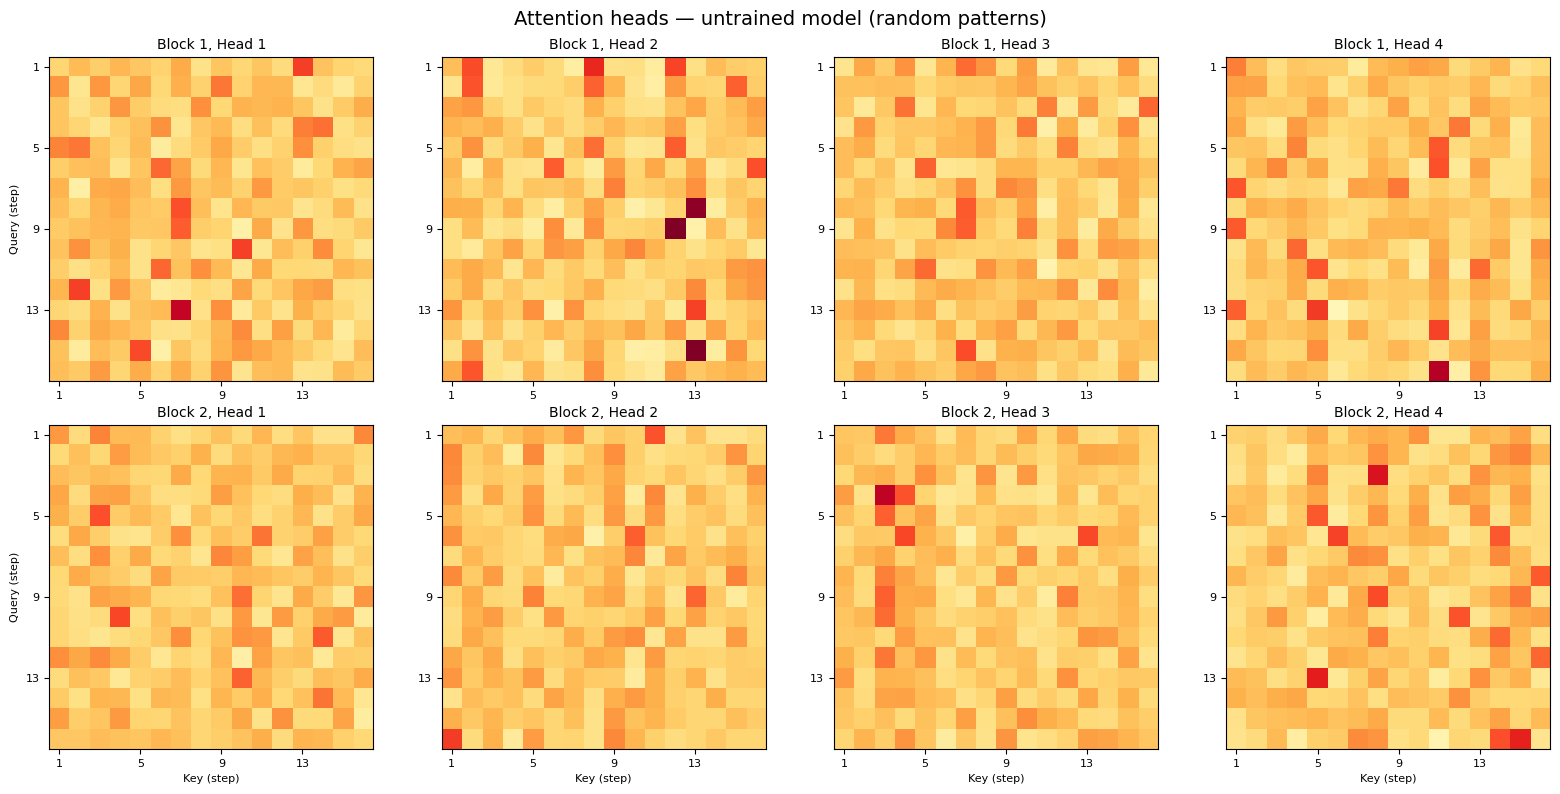

These are random attention patterns (model is untrained).
After training on real beats, you'd expect to see:
  - Some heads with diagonal patterns (self-similarity)
  - Some heads with column patterns (all steps attend to strong beats)
  - Some heads with block patterns (grouping beats 1-4, 5-8, etc.)


In [14]:
# attn_weights[block][batch, head, step, step]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Attention heads — untrained model (random patterns)", fontsize=14)

step_labels = [str(i+1) for i in range(16)]

for block_idx in range(2):
    for head_idx in range(4):
        ax = axes[block_idx][head_idx]
        w = attn_weights[block_idx][0, head_idx].detach().numpy()  # (16, 16)
        im = ax.imshow(w, cmap='YlOrRd', vmin=0, vmax=0.2)
        ax.set_title(f"Block {block_idx+1}, Head {head_idx+1}", fontsize=10)
        ax.set_xticks(range(0, 16, 4))
        ax.set_xticklabels(['1', '5', '9', '13'], fontsize=8)
        ax.set_yticks(range(0, 16, 4))
        ax.set_yticklabels(['1', '5', '9', '13'], fontsize=8)
        if block_idx == 1:
            ax.set_xlabel("Key (step)", fontsize=8)
        if head_idx == 0:
            ax.set_ylabel(f"Query (step)", fontsize=8)

plt.tight_layout()
plt.show()

print("These are random attention patterns (model is untrained).")
print("After training on real beats, you'd expect to see:")
print("  - Some heads with diagonal patterns (self-similarity)")
print("  - Some heads with column patterns (all steps attend to strong beats)")
print("  - Some heads with block patterns (grouping beats 1-4, 5-8, etc.)")



<h3><center>5.6 Test with a random (fake) beat vs our real beat</center></h3>


In [15]:
# Generate a random beat grid (fake)
torch.manual_seed(99)
fake_grid = (torch.rand(1, 4, 16) > 0.5).float()

# Compare
disc.eval()
with torch.no_grad():
    real_prob, _ = disc(beat_grid_batch)
    fake_prob, _ = disc(fake_grid)

print("Discriminator predictions (UNTRAINED — both should be ~0.5):")
print(f"  Real beat (four-on-the-floor):  P(real) = {real_prob.item():.4f}")
print(f"  Random beat (noise):            P(real) = {fake_prob.item():.4f}")
print()
print("After training, we want:")
print(f"  Real beat → P(real) ≈ 1.0")
print(f"  Fake beat → P(real) ≈ 0.0")
print()

# Show what the fake beat looks like
print("Random fake beat grid:")
instruments = ['Kick', 'Snare', 'Hi-hat', 'Clap']
for i, inst in enumerate(instruments):
    row = fake_grid[0, i].int().tolist()
    print(f"  {inst:8s}: {row}")
print(f"  Onset density: {fake_grid.sum().item() / fake_grid[0].numel():.2f} (real was {beat_grid.sum() / beat_grid.size:.2f})")


Discriminator predictions (UNTRAINED — both should be ~0.5):
  Real beat (four-on-the-floor):  P(real) = 0.5206
  Random beat (noise):            P(real) = 0.5252

After training, we want:
  Real beat → P(real) ≈ 1.0
  Fake beat → P(real) ≈ 0.0

Random fake beat grid:
  Kick    : [0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1]
  Snare   : [1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0]
  Hi-hat  : [0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0]
  Clap    : [1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1]
  Onset density: 0.58 (real was 0.25)


<h2><center>6. Training the discriminator</center></h2>

Now we train the discriminator to tell real beats from fake ones. This section contains the actual training code you'll use in your project.

<h3><center>6.1 Negative example generators</center></h3>

Three types of fake beats for training, each teaching the discriminator something different:
- **Random** — completely random grids; catches obviously non-musical garbage
- **Shuffled** — real patterns on wrong instruments; catches wrong instrument assignment
- **Agent-generated** — beats from your PPO agent; catches the specific mistakes YOUR agent makes

Plus a bonus fourth type:
- **Density-wrong** — grids that are way too sparse or too dense; catches unrealistic density

Your proposal specifies the first three. We added density-wrong as an extra training signal since it's easy to generate and helps the discriminator learn density norms.


In [16]:
# Using imports from cell 2

class NegativeGenerator:
    """Generates fake beat grids for discriminator training."""
    
    @staticmethod
    def random_grid(num_instruments=4, num_steps=16, density_range=(0.1, 0.7)):
        """Completely random grid. Easiest negative — no musical structure at all."""
        density = np.random.uniform(*density_range)
        grid = (np.random.rand(num_instruments, num_steps) < density).astype(np.float32)
        return grid
    
    @staticmethod
    def shuffled_grid(real_grid):
        """
        Take a real beat and shuffle the instrument rows.
        The PATTERNS are real, but they're on the WRONG instruments.
        E.g., kick pattern ends up on hi-hat row → sounds wrong.
        This teaches the discriminator that instrument assignment matters.
        """
        grid = real_grid.copy()
        np.random.shuffle(grid)  # Shuffle rows (instruments)
        return grid
    
    @staticmethod
    def density_wrong_grid(num_instruments=4, num_steps=16):
        """Grid with wrong density — either way too sparse or way too dense."""
        if np.random.rand() > 0.5:
            density = np.random.uniform(0.0, 0.1)   # Too sparse
        else:
            density = np.random.uniform(0.8, 1.0)    # Too dense
        grid = (np.random.rand(num_instruments, num_steps) < density).astype(np.float32)
        return grid

# Demo
neg_gen = NegativeGenerator()

print("Random negative:")
print(neg_gen.random_grid())
print(f"\nShuffled negative (from our real beat):")
print(neg_gen.shuffled_grid(beat_grid.astype(np.float32)))
print(f"\nDensity-wrong negative:")
print(neg_gen.density_wrong_grid())



Random negative:
[[0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0.]
 [0. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 1.]]

Shuffled negative (from our real beat):
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]

Density-wrong negative:
[[1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]]


<h3><center>6.2 Dataset class</center></h3>

For now, we'll create synthetic "real" beats based on common drum patterns since we don't have the Groove MIDI .npy files in this notebook. When you connect Taha's data pipeline, you'll swap in the actual Groove MIDI grids.


In [17]:
class BeatDataset(Dataset):
    """
    Dataset for discriminator training.
    
    In the real project: load from Taha's processed Groove MIDI .npy files
    For now: generates synthetic real beats + negatives on the fly
    """
    def __init__(self, real_grids, neg_generator, agent_pool=None, num_samples=5000):
        self.real_grids = real_grids          # numpy array (N, 4, 16)
        self.neg_gen = neg_generator
        self.agent_pool = agent_pool or []     # Historical agent outputs (added during PPO training)
        self.num_samples = num_samples
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        if np.random.rand() < 0.5:
            # REAL beat — label = 1
            i = np.random.randint(len(self.real_grids))
            grid = self.real_grids[i].astype(np.float32)
            label = 1.0
        else:
            # FAKE beat — label = 0
            # Choose negative type randomly
            neg_type = np.random.choice(['random', 'shuffled', 'density', 'agent'],
                                         p=[0.3, 0.3, 0.2, 0.2])
            
            if neg_type == 'agent' and len(self.agent_pool) > 0:
                # Use a beat the PPO agent generated
                i = np.random.randint(len(self.agent_pool))
                grid = self.agent_pool[i].astype(np.float32)
            elif neg_type == 'shuffled':
                i = np.random.randint(len(self.real_grids))
                grid = self.neg_gen.shuffled_grid(self.real_grids[i])
            elif neg_type == 'density':
                grid = self.neg_gen.density_wrong_grid()
            else:
                grid = self.neg_gen.random_grid()
            
            label = 0.0
        
        return torch.tensor(grid), torch.tensor([label])


def generate_synthetic_real_beats(n=1000):
    """
    Generate synthetic 'real' drum patterns for testing.
    
    # TODO: Replace with Taha's processed Groove MIDI data:
    #   real_beats = np.load('data/groove_midi_grids.npy')  # shape: (42133, 4, 16)
    #   Expected format: numpy array, dtype float32, values 0.0 or 1.0
    #   Each grid: (4 instruments, 16 steps)
    """
    grids = []
    for _ in range(n):
        grid = np.zeros((4, 16), dtype=np.float32)
        
        # Kick: strong beats with some variation
        pattern_type = np.random.choice(['four_on_floor', 'syncopated', 'half_time'])
        if pattern_type == 'four_on_floor':
            grid[0, [0, 4, 8, 12]] = 1
        elif pattern_type == 'syncopated':
            grid[0, [0, 6, 10, 12]] = 1
        else:
            grid[0, [0, 8]] = 1
        
        # Snare: backbeats with variation
        if np.random.rand() > 0.3:
            grid[1, [4, 12]] = 1  # Standard backbeat
        else:
            grid[1, [4, 10, 12]] = 1  # With ghost note
        
        # Hi-hat: regular patterns
        hh_type = np.random.choice(['8ths', '16ths', 'offbeat'])
        if hh_type == '8ths':
            grid[2, ::2] = 1  # Every other step
        elif hh_type == '16ths':
            grid[2, :] = 1    # Every step
        else:
            grid[2, 1::2] = 1  # Off-beats
        
        # Clap: sometimes layered with snare
        if np.random.rand() > 0.5:
            grid[3] = grid[1].copy()  # Same as snare
        
        grids.append(grid)
    
    return np.array(grids)


# Create dataset
real_beats = generate_synthetic_real_beats(n=1000)
print(f"Generated {len(real_beats)} synthetic real beats")
print(f"Shape: {real_beats.shape}")
print(f"Average onset density: {real_beats.mean():.3f}")

dataset = BeatDataset(real_beats, NegativeGenerator(), num_samples=4000)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Check one batch
grids, labels = next(iter(dataloader))
print(f"\nBatch — grids: {grids.shape}, labels: {labels.shape}")
print(f"Real beats in batch: {labels.sum().int().item()} / {len(labels)}")



Generated 1000 synthetic real beats
Shape: (1000, 4, 16)
Average onset density: 0.271

Batch — grids: torch.Size([32, 4, 16]), labels: torch.Size([32, 1])
Real beats in batch: 16 / 32


<h3><center>6.3 Training loop</center></h3>

Binary cross-entropy loss with label smoothing. Label smoothing means instead of hard 0/1 targets, we use 0.05/0.95 — this prevents the discriminator from becoming overconfident and makes training more stable.


In [18]:
def train_discriminator(
    disc,
    dataloader,
    epochs=20,
    lr=3e-4,
    label_smoothing=0.1,
    device='cpu',
):
    """
    Train the discriminator.
    
    Label smoothing: instead of targets being exactly 0 and 1,
    we use (label_smoothing/2) and (1 - label_smoothing/2).
    This prevents overconfidence and improves generalization.
    """
    disc = disc.to(device)
    disc.train()
    
    optimizer = torch.optim.Adam(disc.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCELoss()
    
    history = {'loss': [], 'accuracy': [], 'real_acc': [], 'fake_acc': []}
    
    for epoch in range(epochs):
        epoch_loss = 0
        correct = 0
        total = 0
        real_correct = 0
        real_total = 0
        fake_correct = 0
        fake_total = 0
        
        for grids, labels in dataloader:
            grids = grids.to(device)
            labels = labels.to(device)
            
            # Label smoothing: 1.0 → 0.95, 0.0 → 0.05
            smooth_labels = labels * (1 - label_smoothing) + label_smoothing / 2
            
            # Forward pass
            preds, _ = disc(grids)
            loss = criterion(preds, smooth_labels)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Track metrics
            epoch_loss += loss.item()
            predicted = (preds > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            # Track real vs fake accuracy separately
            real_mask = labels == 1.0
            fake_mask = labels == 0.0
            if real_mask.any():
                real_correct += (predicted[real_mask] == labels[real_mask]).sum().item()
                real_total += real_mask.sum().item()
            if fake_mask.any():
                fake_correct += (predicted[fake_mask] == labels[fake_mask]).sum().item()
                fake_total += fake_mask.sum().item()
        
        avg_loss = epoch_loss / len(dataloader)
        accuracy = correct / total
        real_acc = real_correct / max(real_total, 1)
        fake_acc = fake_correct / max(fake_total, 1)
        
        history['loss'].append(avg_loss)
        history['accuracy'].append(accuracy)
        history['real_acc'].append(real_acc)
        history['fake_acc'].append(fake_acc)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Acc: {accuracy:.3f} | "
                  f"Real acc: {real_acc:.3f} | "
                  f"Fake acc: {fake_acc:.3f}")
    
    return history

print("Training function defined!")


Training function defined!


<h3><center>6.4 Train it!</center></h3>


In [19]:
# Create a fresh discriminator
disc = BeatDiscriminator(
    num_instruments=4,
    num_steps=16,
    d_model=64,
    num_heads=4,
    num_blocks=2,
    d_ff=256,
    dropout=0.1,
)

# Train
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Training on: {device}")
print(f"Dataset: {len(dataset)} samples, batch size 32")
print()

history = train_discriminator(disc, dataloader, epochs=30, lr=3e-4, device=device)


Training on: mps
Dataset: 4000 samples, batch size 32

Epoch   1/30 | Loss: 0.4470 | Acc: 0.864 | Real acc: 0.869 | Fake acc: 0.858
Epoch   5/30 | Loss: 0.2507 | Acc: 0.979 | Real acc: 0.998 | Fake acc: 0.961
Epoch  10/30 | Loss: 0.2333 | Acc: 0.985 | Real acc: 0.998 | Fake acc: 0.971
Epoch  15/30 | Loss: 0.2336 | Acc: 0.986 | Real acc: 0.998 | Fake acc: 0.975
Epoch  20/30 | Loss: 0.2367 | Acc: 0.984 | Real acc: 0.999 | Fake acc: 0.969
Epoch  25/30 | Loss: 0.2255 | Acc: 0.990 | Real acc: 1.000 | Fake acc: 0.980
Epoch  30/30 | Loss: 0.2265 | Acc: 0.990 | Real acc: 1.000 | Fake acc: 0.980


<h3><center>6.5 Training curves</center></h3>


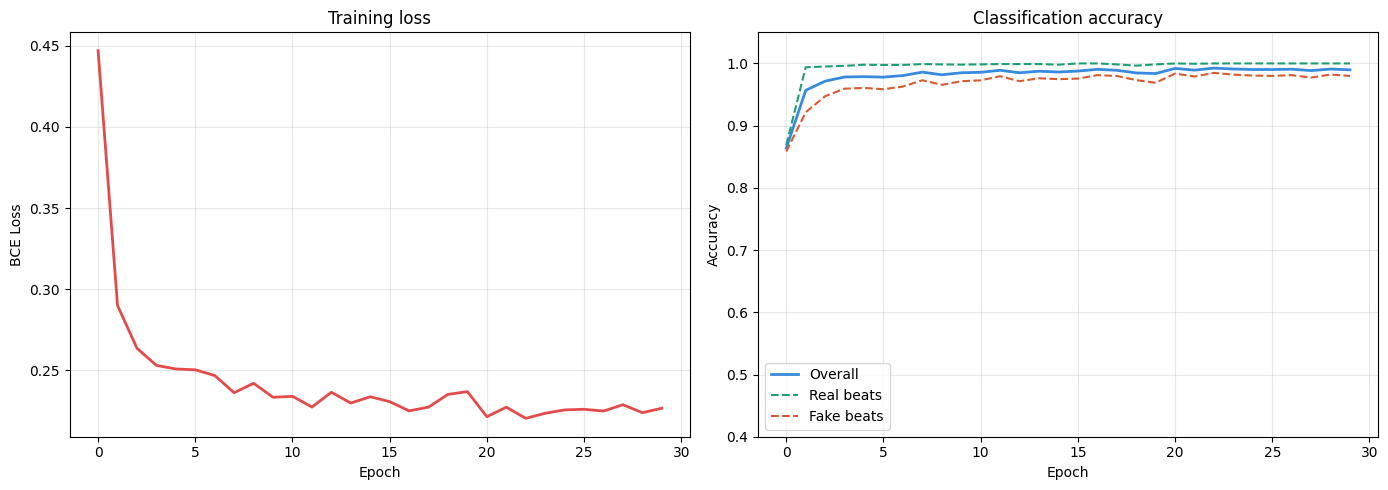


Final accuracy: 0.990
Final real accuracy: 1.000
Final fake accuracy: 0.980


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['loss'], color='#E24B4A', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('Training loss')
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(history['accuracy'], color='#378ADD', linewidth=2, label='Overall')
ax2.plot(history['real_acc'], color='#1D9E75', linewidth=1.5, linestyle='--', label='Real beats')
ax2.plot(history['fake_acc'], color='#D85A30', linewidth=1.5, linestyle='--', label='Fake beats')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Classification accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.4, 1.05)

plt.tight_layout()
plt.show()

print(f"\nFinal accuracy: {history['accuracy'][-1]:.3f}")
print(f"Final real accuracy: {history['real_acc'][-1]:.3f}")
print(f"Final fake accuracy: {history['fake_acc'][-1]:.3f}")


<h3><center>6.6 Test the trained discriminator</center></h3>


In [22]:
disc.eval()
disc_device = next(disc.parameters()).device

# Test on our known beat
real_beat = torch.tensor(beat_grid, dtype=torch.float32).unsqueeze(0).to(disc_device)

# Test on a random grid
torch.manual_seed(42)
fake_beat = (torch.rand(1, 4, 16) > 0.5).float().to(disc_device)

# Test on a shuffled real beat
shuffled = beat_grid.copy()
np.random.shuffle(shuffled)
shuffled_beat = torch.tensor(shuffled, dtype=torch.float32).unsqueeze(0).to(disc_device)

with torch.no_grad():
    real_prob, _ = disc(real_beat)
    fake_prob, _ = disc(fake_beat)
    shuffled_prob, _ = disc(shuffled_beat)

print("Trained discriminator predictions:")
print(f"  Real beat (four-on-the-floor):  P(real) = {real_prob.item():.4f}  {'✓' if real_prob.item() > 0.5 else '✗'}")
print(f"  Random beat (noise):            P(real) = {fake_prob.item():.4f}  {'✓' if fake_prob.item() < 0.5 else '✗'}")
print(f"  Shuffled beat (wrong rows):     P(real) = {shuffled_prob.item():.4f}  {'✓' if shuffled_prob.item() < 0.5 else '✗'}")


Trained discriminator predictions:
  Real beat (four-on-the-floor):  P(real) = 0.9406  ✓
  Random beat (noise):            P(real) = 0.0424  ✓
  Shuffled beat (wrong rows):     P(real) = 0.0436  ✓


<h3><center>6.7 Visualize trained attention patterns</center></h3>


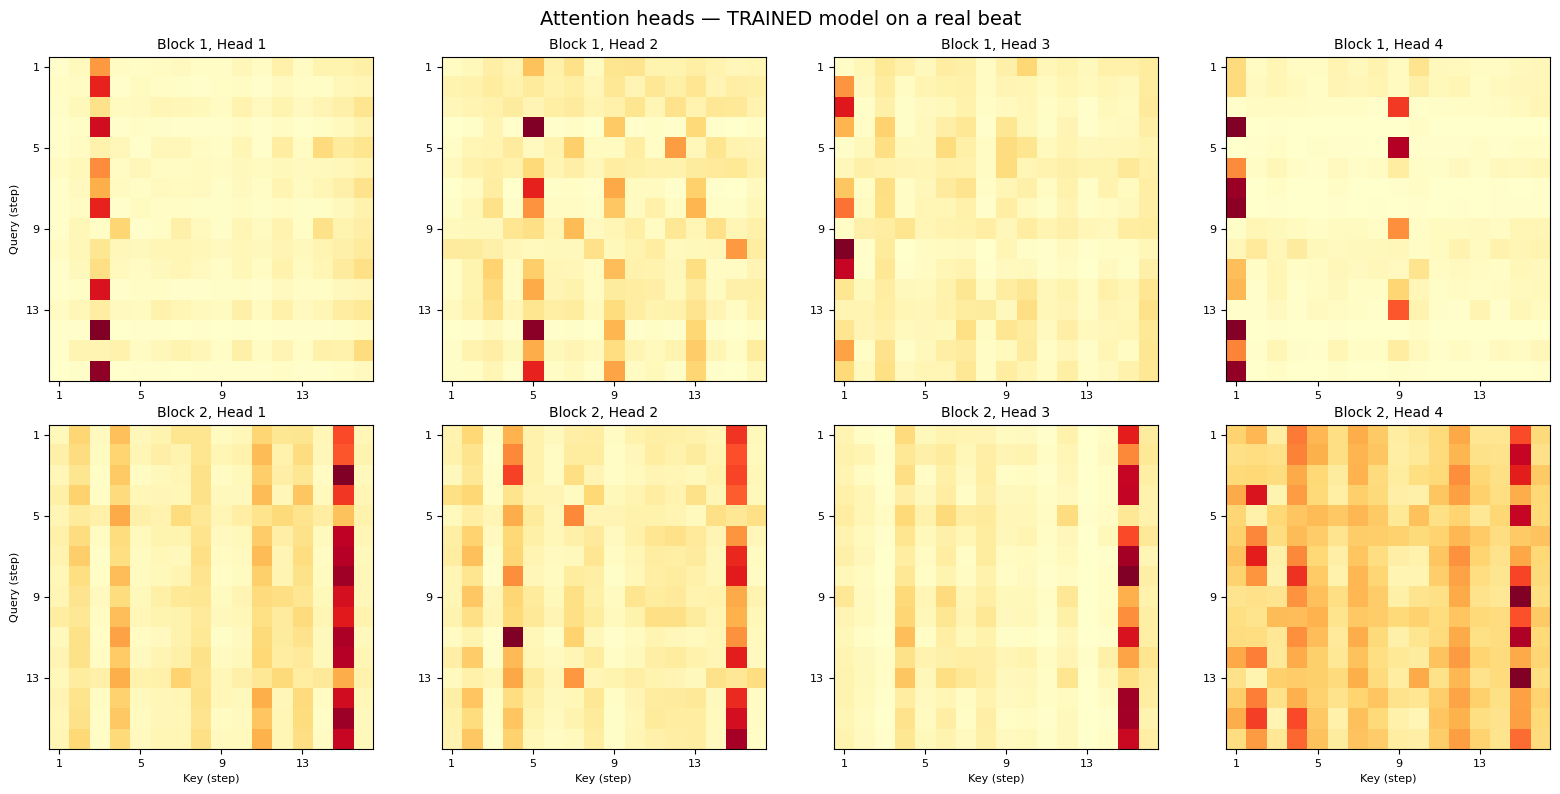

Compare these with the untrained attention maps from section 5.5!
Trained heads should show more structured patterns — columns, diagonals, blocks.
Each head may have specialized in a different musical feature.


In [23]:
# Get attention weights from a real beat
disc.eval()
with torch.no_grad():
    _, attn_weights = disc(real_beat)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Attention heads — TRAINED model on a real beat", fontsize=14)

for block_idx in range(2):
    for head_idx in range(4):
        ax = axes[block_idx][head_idx]
        w = attn_weights[block_idx][0, head_idx].cpu().detach().numpy()
        im = ax.imshow(w, cmap='YlOrRd', vmin=0)
        ax.set_title(f"Block {block_idx+1}, Head {head_idx+1}", fontsize=10)
        ax.set_xticks(range(0, 16, 4))
        ax.set_xticklabels(['1', '5', '9', '13'], fontsize=8)
        ax.set_yticks(range(0, 16, 4))
        ax.set_yticklabels(['1', '5', '9', '13'], fontsize=8)
        if block_idx == 1:
            ax.set_xlabel("Key (step)", fontsize=8)
        if head_idx == 0:
            ax.set_ylabel(f"Query (step)", fontsize=8)

plt.tight_layout()
plt.show()

print("Compare these with the untrained attention maps from section 5.5!")
print("Trained heads should show more structured patterns — columns, diagonals, blocks.")
print("Each head may have specialized in a different musical feature.")


<h3><center>Section 6 summary</center></h3>

| Component | Details |
|---|---|
| **Negatives** | Random (30%), shuffled (30%), density-wrong (20%), agent-generated (20%) |
| **Label smoothing** | ε = 0.1 → targets are 0.05 and 0.95 instead of 0 and 1 |
| **Optimizer** | Adam, lr=3e-4, weight_decay=1e-5 |
| **Loss** | Binary cross-entropy |
| **During PPO training** | Discriminator updates every 100 episodes, uses agent pool of 500 recent beats |

<h3><center>What to swap for real training:</center></h3>
1. Replace `generate_synthetic_real_beats()` with `np.load('data/groove_midi_grids.npy')` from Taha's pipeline (shape: 42133, 4, 16)
2. Add agent pool updates in the PPO training loop (pool of 500 recent agent beats)
3. Move to GPU on the HPC cluster (`device='cuda'`) for faster training

---